# Data PreProcessing, Model Training, Evaluation and Deployment

In [1]:
### Data PreProcessing 
# ITBNM-2211-0136 (J M P M Jayakody)

### Model Training - 
# ITBNM-2211-0181 (M P S J Rathnayaka) - RandomForest
# ITBNM-2211-0129 (W S N Fernando)  - Linear Regression
# ITBNM-2211-0144 (G D V Lakshan) -SVM 
# ITBNM-2211-0132 (K G D K Gunasekara) -Knn

### Evaluation and Deployment 
# ITBNM-2211-0129 (W S N Fernando)

### Understanding the Dataset

In [2]:
# Importing essential modules for data exploration, visualization, data separation, model training and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [3]:
# Load the dataset and create a dataframe
file_path = 'mobile_prices_2023.csv'
data = pd.read_csv(file_path)
df = pd.DataFrame(data)

In [4]:
df.head()

,Phone Name,Rating ?/5,Number of Ratings,RAM,ROM/Storage,Back/Rare Camera,Front Camera,Battery,Processor,Price in INR,Date of Scraping
0,"POCO C50 (Royal Blue, 32 GB)",4.2,"33,561",2 GB RAM,32 GB ROM,8MP Dual Camera,5MP Front Camera,5000 mAh,"Mediatek Helio A22 Processor, Upto 2.0 GHz Pro...","₹5,649",2023-06-17
1,"POCO M4 5G (Cool Blue, 64 GB)",4.2,"77,128",4 GB RAM,64 GB ROM,50MP + 2MP,8MP Front Camera,5000 mAh,Mediatek Dimensity 700 Processor,"₹11,999",2023-06-17
2,"POCO C51 (Royal Blue, 64 GB)",4.3,"15,175",4 GB RAM,64 GB ROM,8MP Dual Rear Camera,5MP Front Camera,5000 mAh,Helio G36 Processor,"₹6,999",2023-06-17
3,"POCO C55 (Cool Blue, 64 GB)",4.2,"22,621",4 GB RAM,64 GB ROM,50MP Dual Rear Camera,5MP Front Camera,5000 mAh,Mediatek Helio G85 Processor,"₹7,749",2023-06-17
4,"POCO C51 (Power Black, 64 GB)",4.3,"15,175",4 GB RAM,64 GB ROM,8MP Dual Rear Camera,5MP Front Camera,5000 mAh,Helio G36 Processor,"₹6,999",2023-06-17


In [5]:
# Checking how many rows and columns are there
df.shape

(1836, 11)

In [6]:
# checking the info on all the data columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Phone Name         1836 non-null   object 
 1   Rating ?/5         1836 non-null   float64
 2   Number of Ratings  1836 non-null   object 
 3   RAM                1836 non-null   object 
 4   ROM/Storage        1662 non-null   object 
 5   Back/Rare Camera   1827 non-null   object 
 6   Front Camera       1435 non-null   object 
 7   Battery            1826 non-null   object 
 8   Processor          1781 non-null   object 
 9   Price in INR       1836 non-null   object 
 10  Date of Scraping   1836 non-null   object 
dtypes: float64(1), object(10)
memory usage: 157.9+ KB


In [7]:
# Checking the column names in the dataset
df.columns

Index(['Phone Name', 'Rating ?/5', 'Number of Ratings', 'RAM', 'ROM/Storage',
       'Back/Rare Camera', 'Front Camera', 'Battery', 'Processor',
       'Price in INR', 'Date of Scraping'],
      dtype='object')

In [8]:
# Checking the data types of the columns
df.dtypes

Phone Name            object
Rating ?/5           float64
Number of Ratings     object
RAM                   object
ROM/Storage           object
Back/Rare Camera      object
Front Camera          object
Battery               object
Processor             object
Price in INR          object
Date of Scraping      object
dtype: object

In [9]:
# checking the unique values in the object type columns in the datasset
object_types = df.select_dtypes(include='object')

for col in object_types.columns:
  print(f"Unique Values in column {col}: {df[col].unique()}")

Unique Values in column Phone Name: ['POCO C50 (Royal Blue, 32 GB)' 'POCO M4 5G (Cool Blue, 64 GB)'
 'POCO C51 (Royal Blue, 64 GB)' ... 'Infinix Note 7 (Aether Black, 64 GB)'
 'Infinix Zero 8i (Silver Diamond, 128 GB)'
 'Infinix S5 (Quetzal Cyan, 64 GB)']
Unique Values in column Number of Ratings: ['33,561' '77,128' '15,175' '22,621' '13,647' '40,525' '7,572' '11,675'
 '21,133' '7,285' '21,688' '3,525' '7,460' '2,646' '54,521' '40,239'
 '85,420' '7,885' '2,683' '2,22,992' '460' '21,576' '48,896' '1,45,794'
 '2,71,753' '56,081' '1,73,304' '60,968' '2,44,650' '5,304' '4,00,433'
 '67,498' '3,52,150' '3,312' '1,37,003' '12,889' '2,49,602' '4,84,582'
 '64,087' '2,56,360' '4,739' '1,25,650' '4,09,478' '56,643' '15,055'
 '12,742' '9,101' '39,053' '13,111' '55,030' '1,04,291' '17,768' '24,728'
 '10,967' '4,676' '4,115' '127' '8,557' '48,258' '17,460' '11,210' '359'
 '51,873' '360' '91,242' '1,89,477' '1,23,959' '25,430' '77,321'
 '2,55,896' '69,800' '63,130' '9,393' '1,74,284' '48,051' '65,343

In [10]:
numeric_types = df.select_dtypes(include=['int64', 'float64'])
print(numeric_types.isnull().sum())
print(object_types.isnull().sum())

Rating ?/5    0
dtype: int64
Phone Name             0
Number of Ratings      0
RAM                    0
ROM/Storage          174
Back/Rare Camera       9
Front Camera         401
Battery               10
Processor             55
Price in INR           0
Date of Scraping       0
dtype: int64


In [11]:
# Checking the five-number summary of the dataset
df.describe()


,Rating ?/5
count,1836.000000
mean,4.210512
std,0.543912
min,0.000000
25%,4.200000
50%,4.300000
75%,4.400000
max,4.800000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Phone Name         1836 non-null   object 
 1   Rating ?/5         1836 non-null   float64
 2   Number of Ratings  1836 non-null   object 
 3   RAM                1836 non-null   object 
 4   ROM/Storage        1662 non-null   object 
 5   Back/Rare Camera   1827 non-null   object 
 6   Front Camera       1435 non-null   object 
 7   Battery            1826 non-null   object 
 8   Processor          1781 non-null   object 
 9   Price in INR       1836 non-null   object 
 10  Date of Scraping   1836 non-null   object 
dtypes: float64(1), object(10)
memory usage: 157.9+ KB


In [13]:
# Convert all string/object columns to integer codes
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category').cat.codes

# Double-check that all columns are numeric now
print(df.dtypes)


Phone Name             int16
Rating ?/5           float64
Number of Ratings      int16
RAM                     int8
ROM/Storage             int8
Back/Rare Camera       int16
Front Camera            int8
Battery                 int8
Processor              int16
Price in INR           int16
Date of Scraping        int8
dtype: object


In [14]:
print(df.select_dtypes(include=['object']).columns)


Index([], dtype='object')


In [15]:
# Convert all booleans to 0/1
df = df.astype(int)

# Fill missing numeric values with mean (or other strategy)
df = df.fillna(df.mean())

# Final check
print(df.dtypes)
print(df.isnull().sum().sum(), "missing values left")


Phone Name           int64
Rating ?/5           int64
Number of Ratings    int64
RAM                  int64
ROM/Storage          int64
Back/Rare Camera     int64
Front Camera         int64
Battery              int64
Processor            int64
Price in INR         int64
Date of Scraping     int64
dtype: object
0 missing values left


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Phone Name         1836 non-null   int64
 1   Rating ?/5         1836 non-null   int64
 2   Number of Ratings  1836 non-null   int64
 3   RAM                1836 non-null   int64
 4   ROM/Storage        1836 non-null   int64
 5   Back/Rare Camera   1836 non-null   int64
 6   Front Camera       1836 non-null   int64
 7   Battery            1836 non-null   int64
 8   Processor          1836 non-null   int64
 9   Price in INR       1836 non-null   int64
 10  Date of Scraping   1836 non-null   int64
dtypes: int64(11)
memory usage: 157.9 KB


In [17]:
df.head()

,Phone Name,Rating ?/5,Number of Ratings,RAM,ROM/Storage,Back/Rare Camera,Front Camera,Battery,Processor,Price in INR,Date of Scraping
0,746,4,427,16,14,171,26,78,187,395,0
1,789,4,642,25,20,118,32,78,173,88,0
2,748,4,186,25,20,172,26,78,106,433,0
3,750,4,309,25,20,137,26,78,193,455,0
4,747,4,186,25,20,172,26,78,106,433,0


In [18]:
for col in numeric_types.columns:
  print(f"{col} = Min value: {df[col].min()} and Max value: {df[col].max()} and IQR: {df[col].quantile()}")

Rating ?/5 = Min value: 0 and Max value: 4 and IQR: 4.0


In [19]:
# Checking out the total number of null values in the dataset, column-wise
df.isnull().sum()

Phone Name           0
Rating ?/5           0
Number of Ratings    0
RAM                  0
ROM/Storage          0
Back/Rare Camera     0
Front Camera         0
Battery              0
Processor            0
Price in INR         0
Date of Scraping     0
dtype: int64

In [20]:
for col in object_types.columns:
  print(f"Unique Values in column {col}: {df[col].unique()}")

Unique Values in column Phone Name: [746 789 748 ... 260 301 263]
Unique Values in column Number of Ratings: [427 642 186 309 165 487 624 140 294 618 296 392 621 269 543 485 680 627
 271 247 505 295 511  65 274 551  89 585 256 520 455 604 391 385  56 154
 260 481 594 265 479  33 461 553 185 151 691 451 159 547   6 208 326 125
 476 462 157 658 510 205 135 441 538 444 704  99  29 334 643 264 613 591
 692  90 509 597 359 240 199  31 325 565 389 346  41 356   9 201 134 251
 282  47 630 584 575 714 423 489 589  70 635 224 214 158 508 679 450 141
 644 587  59 667 371 598 344 381 286 420  27  32 507 533 128 183 499 629
  46 683  42 248 443 107 122  98  68  44  67 100 387 608  74   2  15 661
  39 709 219 713  14 331  71 184 115 103 258 281 236 112 458 495 646 380
 497 390  24  87  21 397 546 463   5 634 632 193 490 645 716 545 599  28
   4 637  82 554 504 469 243   7   0 636 502 595 262 321 496 628 367 410
  76 705 606 569   8 246 366 601 364 180 706  81 614 104 681 482 270  51
 194  20 290  7

In [21]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Ensure columns are string before extracting numbers
df['RAM'] = df['RAM'].astype(str).str.extract('(\d+)').astype(float)
df['ROM/Storage'] = df['ROM/Storage'].astype(str).str.extract('(\d+)').astype(float)
df['Battery'] = df['Battery'].astype(str).str.extract('(\d+)').astype(float)

# Drop rows with any remaining missing values
df.dropna(inplace=True)


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Dell\AppData\Local\Temp\ipykernel_9748\3499133840.py:5: SyntaxWarning: invalid escape sequence '\d'
  df['RAM'] = df['RAM'].astype(str).str.extract('(\d+)').astype(float)
C:\Users\Dell\AppData\Local\Temp\ipykernel_9748\3499133840.py:6: SyntaxWarning: invalid escape sequence '\d'
  df['ROM/Storage'] = df['ROM/Storage'].astype(str).str.extract('(\d+)').astype(float)
C:\Users\Dell\AppData\Local\Temp\ipykernel_9748\3499133840.py:7: SyntaxWarning: invalid escape sequence '\d'
  df['Battery'] = df['Battery'].astype(str).str.extract('(\d+)').astype(float)


In [22]:
df.dtypes

Phone Name             int64
Rating ?/5             int64
Number of Ratings      int64
RAM                  float64
ROM/Storage          float64
Back/Rare Camera       int64
Front Camera           int64
Battery              float64
Processor              int64
Price in INR           int64
Date of Scraping       int64
dtype: object

In [23]:
print("Number of features with numerical values:",len(df.select_dtypes(include='int64').columns))

Number of features with numerical values: 8


In [24]:
print("Number of features with Categorical values", len(df.select_dtypes(include='object').columns))

Number of features with Categorical values 0


In [25]:
print("Features with Categorical values:", df.select_dtypes(include='object').columns)

Features with Categorical values: Index([], dtype='object')


## Exploratory Data Analysis

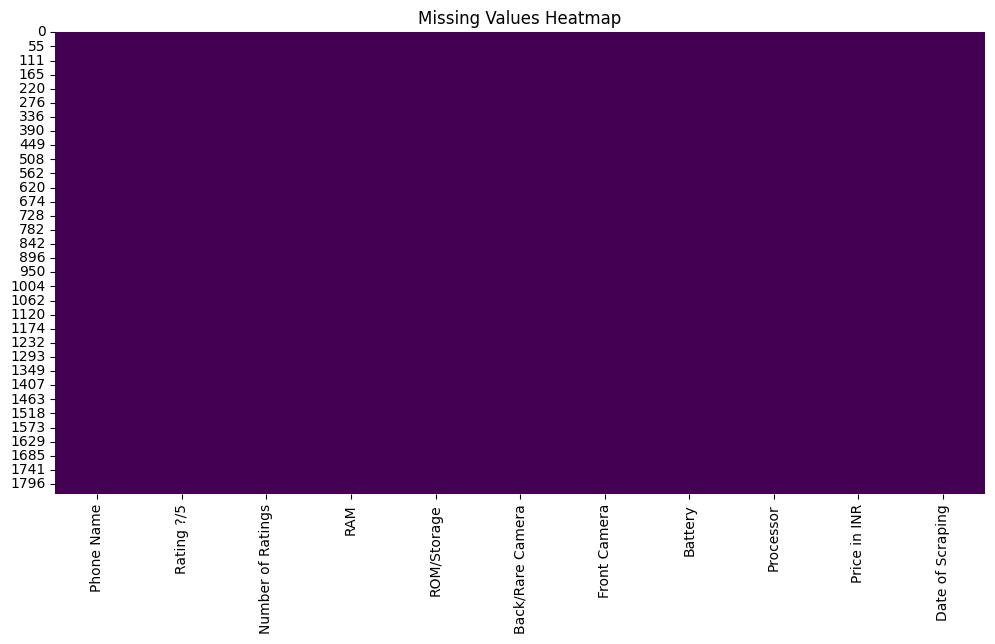

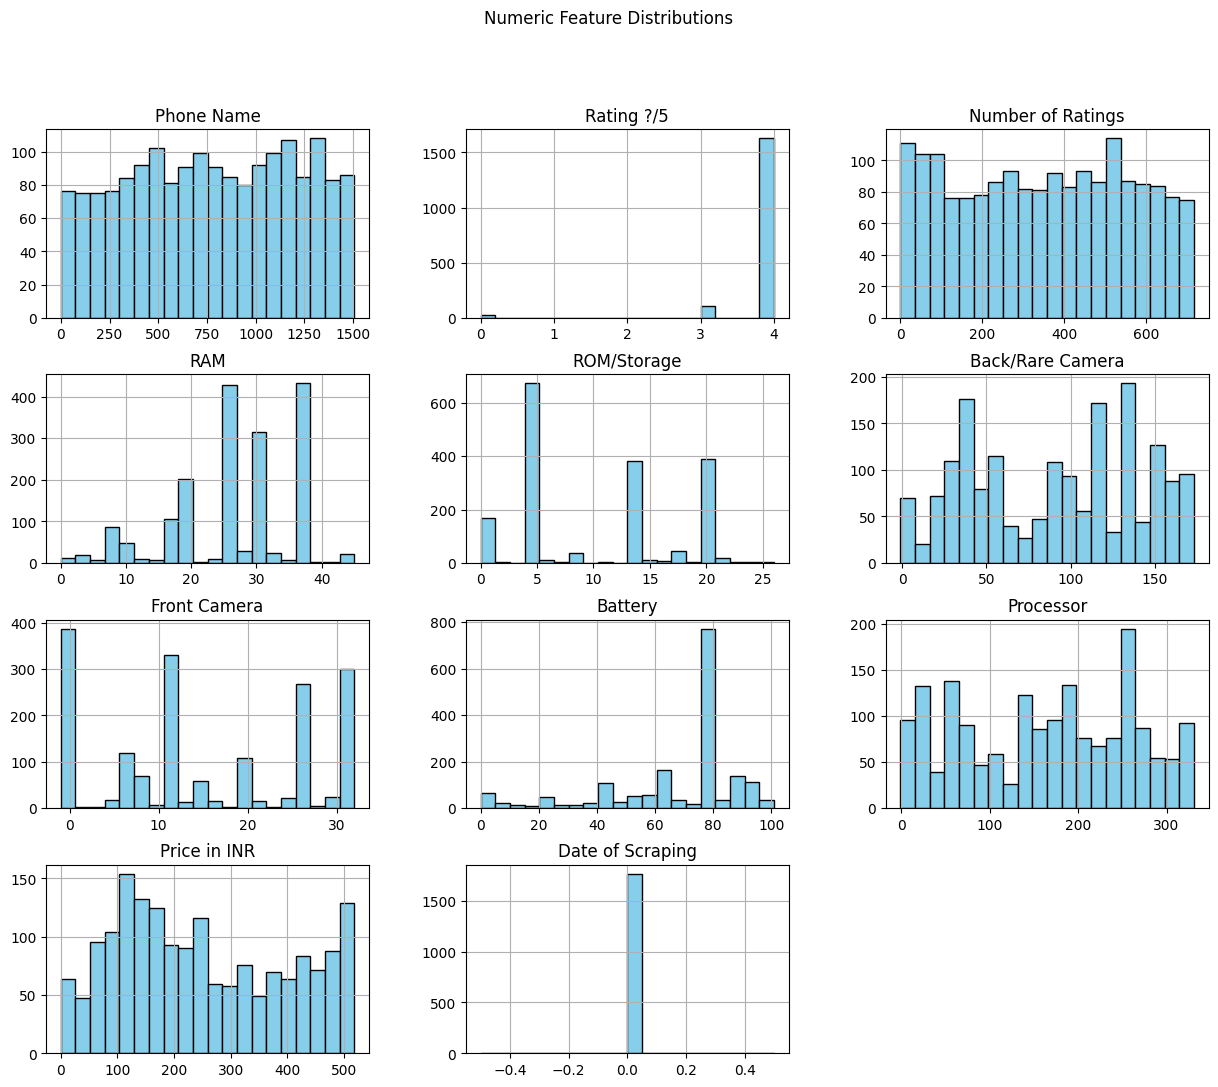

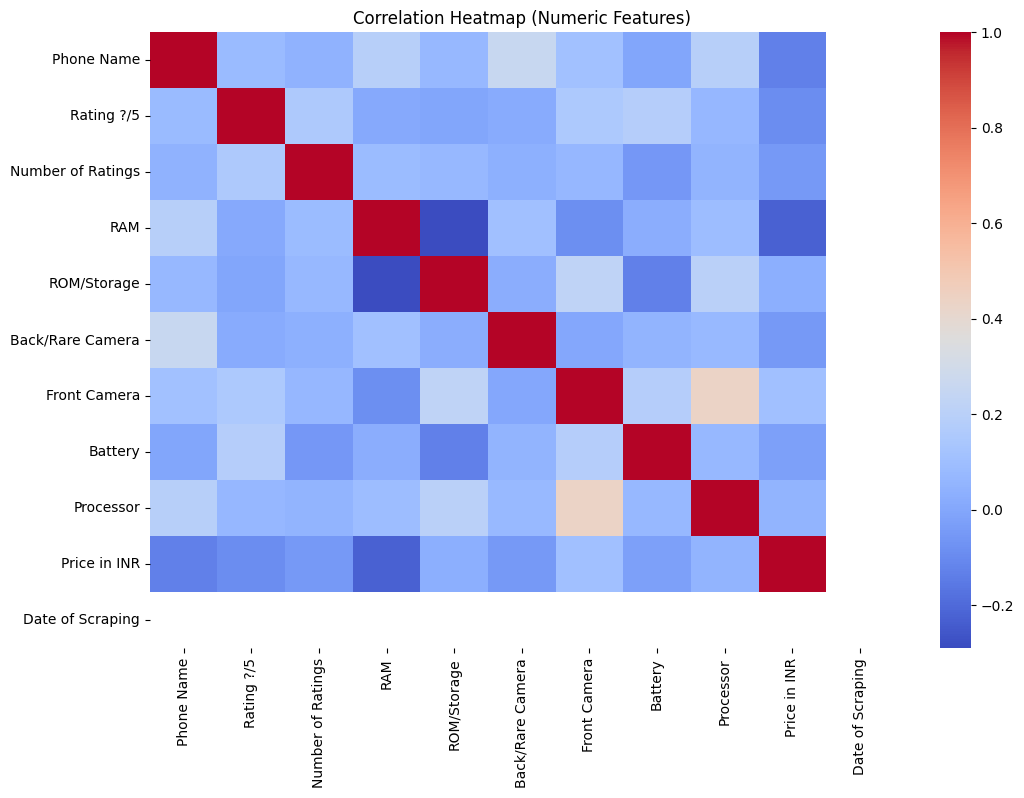

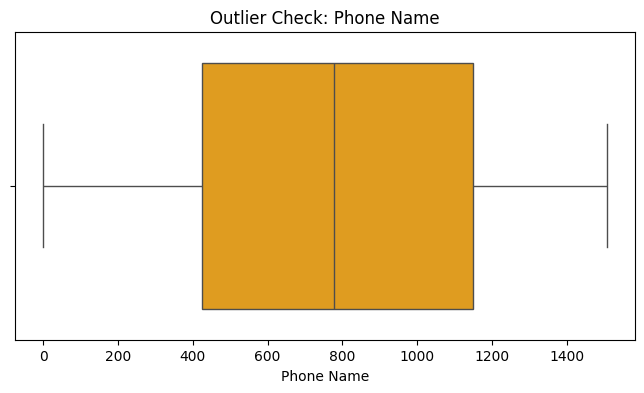

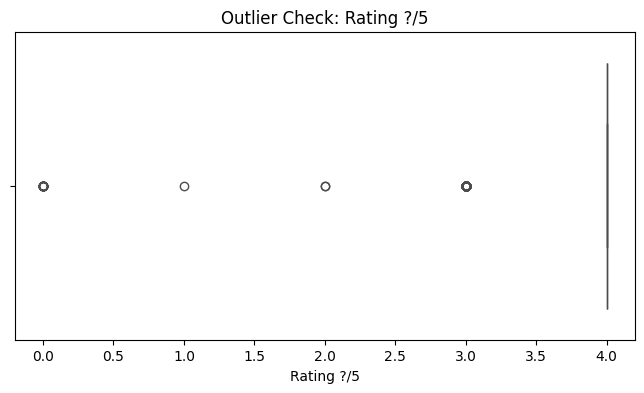

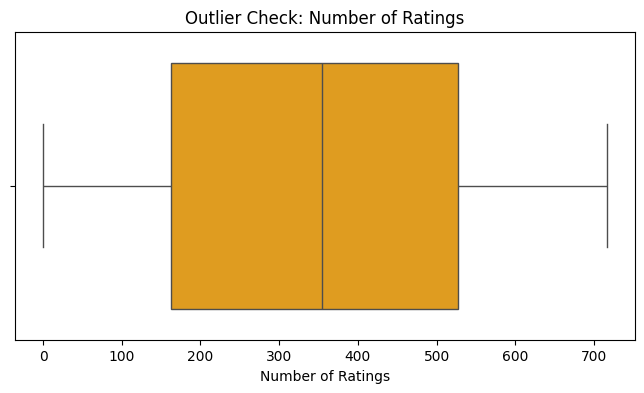

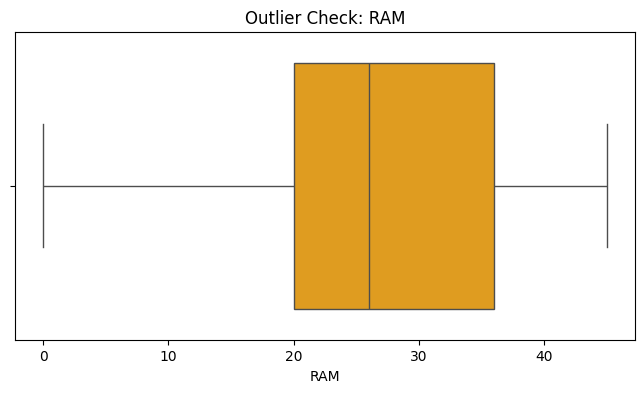

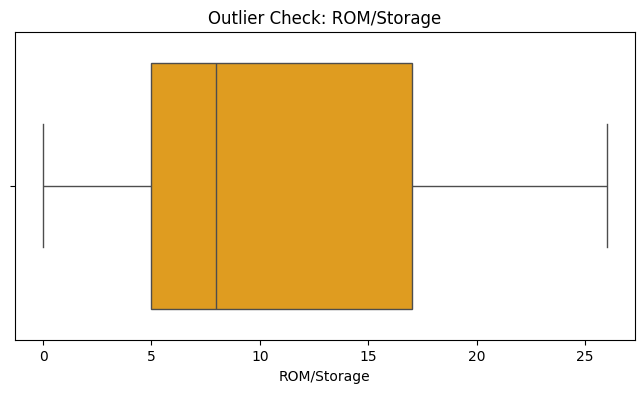

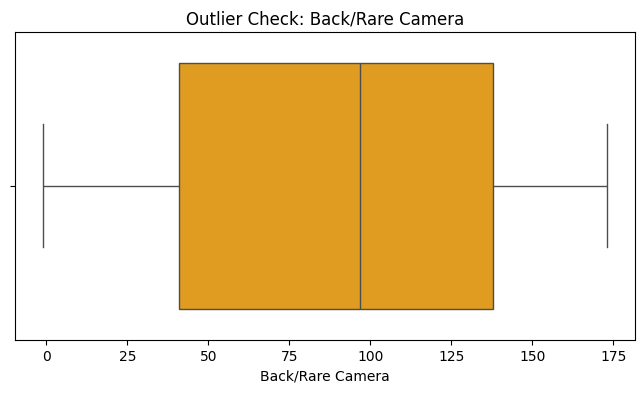

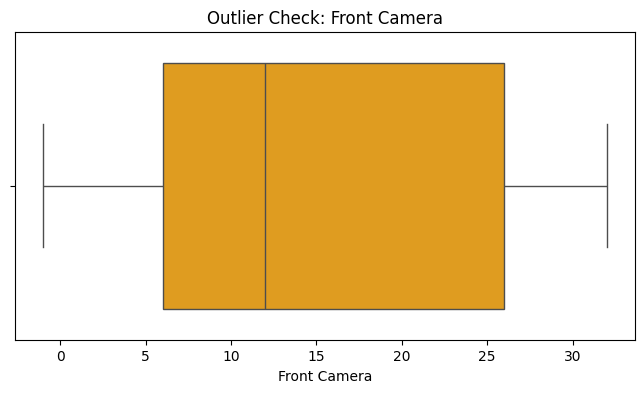

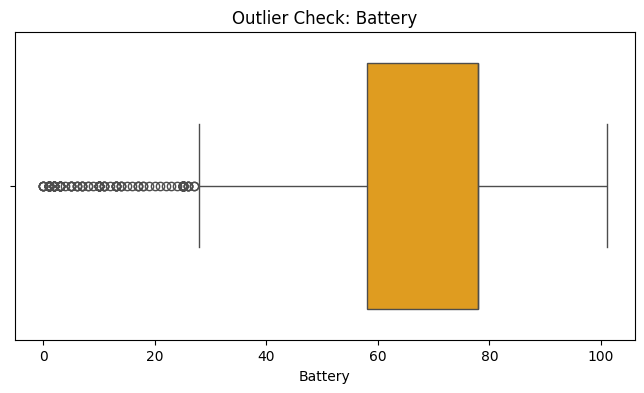

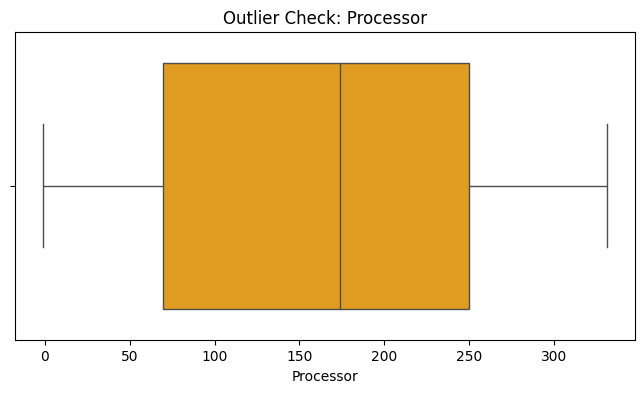

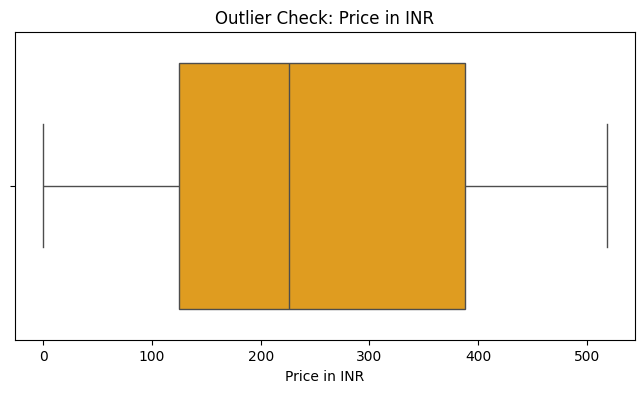

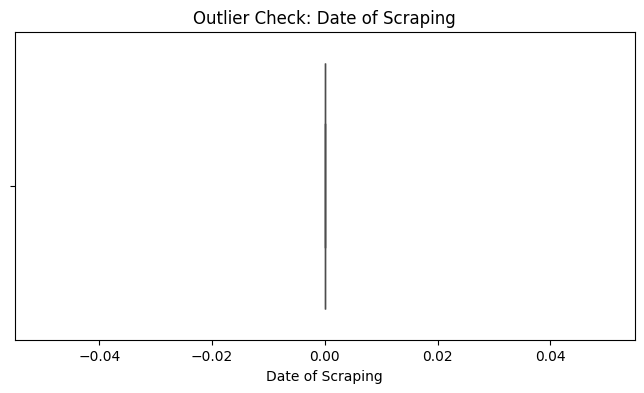

In [26]:

# 1. Missing values heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# 2. Numeric distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].hist(bins=20, figsize=(15, 12), color='skyblue', edgecolor='black')
plt.suptitle("Numeric Feature Distributions")
plt.show()

# 3. Categorical counts
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='viridis')
    plt.title(f"Category Counts: {col}")
    plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# 5. Outlier detection (boxplots)
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f"Outlier Check: {col}")
    plt.show()

# 6. Price vs top features scatterplots
target = 'Price_INR'
if target in df.columns:
    top_corr_features = corr[target].abs().sort_values(ascending=False)[1:6].index
    for feature in top_corr_features:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=df[feature], y=df[target], alpha=0.5)
        plt.title(f"{feature} vs {target}")
        plt.show()

# 7. Feature importance (RandomForest)
from sklearn.ensemble import RandomForestRegressor

df_clean = df.copy()
# Convert categoricals
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype('category').cat.codes

df_clean = df_clean.dropna()
if target in df_clean.columns:
    X = df_clean.drop(target, axis=1)
    y = df_clean[target]
    rf = RandomForestRegressor(random_state=42)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances, y=importances.index, palette='coolwarm')
    plt.title("Feature Importance")
    plt.show()


## Feature Encoding

In [27]:
# One-hot encode the 'Processor' column as an example
df = pd.get_dummies(df, columns=['Processor'], drop_first=True)


## Model Training

In [28]:
#ITBNM-2211-0181
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('Price in INR', axis=1)
y = df['Price in INR']

# Select only numeric columns for scaling
X_numeric = X.select_dtypes(include=[np.number])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)


# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)





In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


MAE: 41.50815580543123
RMSE: 79.80094092879668
R² Score: 0.731322978143339
           Model  R2 Score        MAE       RMSE
0  Random Forest  0.731323  41.508156  79.800941


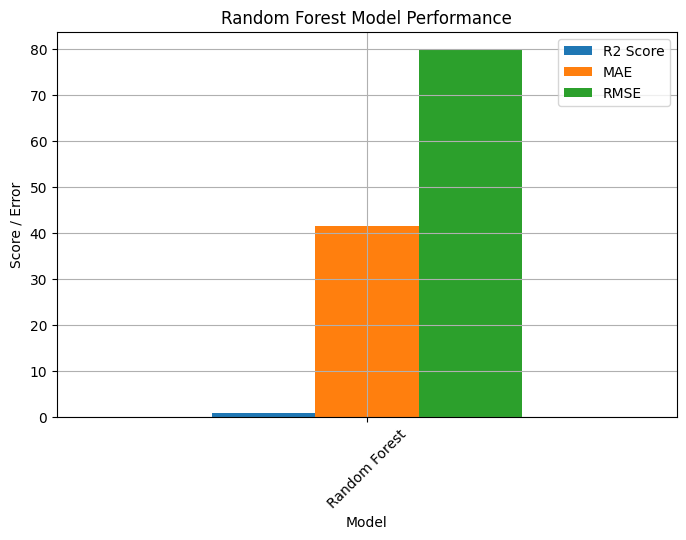

In [30]:
from sklearn.metrics import mean_squared_error

# Calculate metrics for Random Forest (already trained and predicted)
rf_rmse = mean_squared_error(y_test, y_pred) ** 0.5
rf_mae = mean_absolute_error(y_test, y_pred)
rf_score = r2_score(y_test, y_pred)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R² Score:", r2_score(y_test, y_pred))

# Create results DataFrame for Random Forest only
results = pd.DataFrame({
    'Model': ['Random Forest'],
    'R2 Score': [rf_score],
    'MAE': [rf_mae],
    'RMSE': [rf_rmse]
})
print(results)

# Plotting
results.set_index('Model')[['R2 Score', 'MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))
plt.title("Random Forest Model Performance")
plt.ylabel("Score / Error")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [31]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Evaluate tuned model
best_rf_pred = best_rf.predict(X_test)
print("Tuned RF R2:", best_rf.score(X_test, y_test))
print("Tuned RF MAE:", mean_absolute_error(y_test, best_rf_pred))


Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RF R2: 0.7265042301420412
Tuned RF MAE: 41.75244809600395


In [32]:
import joblib

# Save model and scaler
joblib.dump(model, 'smartphone_price_predictor.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

ITBNM-2211-0129 (Linear Regression Model Training)

Import libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


Prepare features and target

In [34]:
# Features and target
X = df.drop('Price in INR', axis=1)
y = df['Price in INR']

# Select only numeric columns for scaling
X_numeric = X.select_dtypes(include=[np.number])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Train Linear Regression model

In [35]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predict and evaluate

In [36]:
import numpy as np

# Predict
y_pred = model.predict(X_test)

# Calculate metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Manual square root
lr_mae = mean_absolute_error(y_test, y_pred)
lr_score = r2_score(y_test, y_pred)

# Display metrics
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_score)


MAE: 123.38826771120517
RMSE: 146.1368364237652
R² Score: 0.09898109272835176


Create results table and plot

               Model  R2 Score         MAE        RMSE
0  Linear Regression  0.098981  123.388268  146.136836


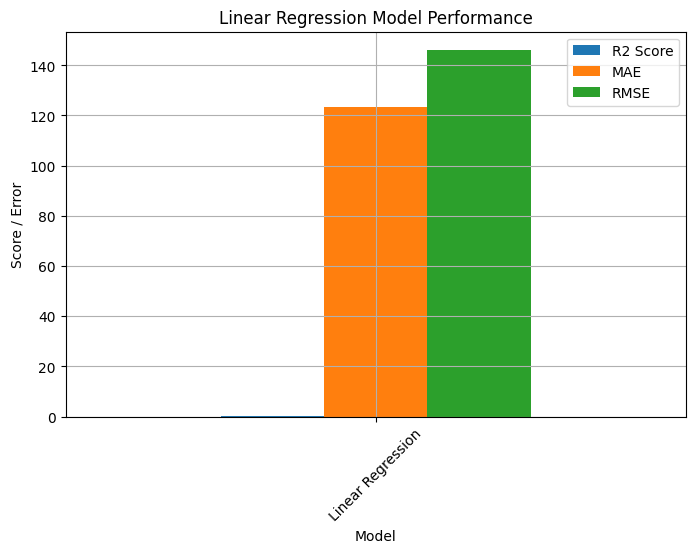

In [37]:
# Create results DataFrame
results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'R2 Score': [lr_score],
    'MAE': [lr_mae],
    'RMSE': [lr_rmse]
})
print(results)

# Plot
results.set_index('Model')[['R2 Score', 'MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))
plt.title("Linear Regression Model Performance")
plt.ylabel("Score / Error")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


Save model and scaler

In [38]:
# Save model and scaler
joblib.dump(model, 'smartphone_price_predictor_linear.pkl')
joblib.dump(scaler, 'scaler_linear.pkl')


['scaler_linear.pkl']

ITBNM-2211-0144 (SVM Model Training)

In [39]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib

In [40]:
df.head()

,Phone Name,Rating ?/5,Number of Ratings,RAM,ROM/Storage,Back/Rare Camera,Front Camera,Battery,Price in INR,Date of Scraping,...,Processor_322,Processor_323,Processor_324,Processor_325,Processor_326,Processor_327,Processor_328,Processor_329,Processor_330,Processor_331
0,746,4,427,16.0,14.0,171,26,78.0,395,0,...,False,False,False,False,False,False,False,False,False,False
1,789,4,642,25.0,20.0,118,32,78.0,88,0,...,False,False,False,False,False,False,False,False,False,False
2,748,4,186,25.0,20.0,172,26,78.0,433,0,...,False,False,False,False,False,False,False,False,False,False
3,750,4,309,25.0,20.0,137,26,78.0,455,0,...,False,False,False,False,False,False,False,False,False,False
4,747,4,186,25.0,20.0,172,26,78.0,433,0,...,False,False,False,False,False,False,False,False,False,False


In [41]:
df.columns

Index(['Phone Name', 'Rating ?/5', 'Number of Ratings', 'RAM', 'ROM/Storage',
       'Back/Rare Camera', 'Front Camera', 'Battery', 'Price in INR',
       'Date of Scraping',
       ...
       'Processor_322', 'Processor_323', 'Processor_324', 'Processor_325',
       'Processor_326', 'Processor_327', 'Processor_328', 'Processor_329',
       'Processor_330', 'Processor_331'],
      dtype='object', length=342)

In [42]:
# Create price ranges for classification
price_quantiles = df["Price in INR"].quantile([0, 0.33, 0.67, 1]).tolist()
price_labels = ["Budget", "Mid-Range", "Premium"]

df["Price_Range"] = pd.cut(
    df["Price in INR"],
    bins=price_quantiles,
    labels=price_labels,
    include_lowest=True
)

In [43]:
df.head(10)

,Phone Name,Rating ?/5,Number of Ratings,RAM,ROM/Storage,Back/Rare Camera,Front Camera,Battery,Price in INR,Date of Scraping,...,Processor_323,Processor_324,Processor_325,Processor_326,Processor_327,Processor_328,Processor_329,Processor_330,Processor_331,Price_Range
0,746,4,427,16.0,14.0,171,26,78.0,395,0,...,False,False,False,False,False,False,False,False,False,Premium
1,789,4,642,25.0,20.0,118,32,78.0,88,0,...,False,False,False,False,False,False,False,False,False,Budget
2,748,4,186,25.0,20.0,172,26,78.0,433,0,...,False,False,False,False,False,False,False,False,False,Premium
3,750,4,309,25.0,20.0,137,26,78.0,455,0,...,False,False,False,False,False,False,False,False,False,Premium
4,747,4,186,25.0,20.0,172,26,78.0,433,0,...,False,False,False,False,False,False,False,False,False,Premium
5,791,4,642,25.0,20.0,118,32,78.0,88,0,...,False,False,False,False,False,False,False,False,False,Budget
6,754,4,309,25.0,20.0,137,26,78.0,455,0,...,False,False,False,False,False,False,False,False,False,Premium
7,752,4,309,25.0,20.0,137,26,78.0,455,0,...,False,False,False,False,False,False,False,False,False,Premium
8,749,4,165,31.0,5.0,137,26,78.0,499,0,...,False,False,False,False,False,False,False,False,False,Premium
9,792,4,487,31.0,5.0,118,32,78.0,123,0,...,False,False,False,False,False,False,False,False,False,Budget


In [44]:
# Prepare Features & Target
# Select features for ML models (using only 4 features as requested)

df = df.rename(columns={
    "Rating ?/5": "Rating",
    "Number of Ratings": "Num_Ratings",
    "ROM/Storage": "ROM_GB",
    "RAM": "RAM_GB"
})

features = ["RAM_GB", "ROM_GB", "Rating", "Num_Ratings"]
existing_features = [f for f in features if f in df.columns]

X = df[existing_features]
y_classification = df["Price_Range"]

# Scale numerical features for classification and clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [45]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_classification, test_size=0.3, random_state=42, stratify=y_classification)

# Support Vector Machine (SVM kernel= linear) Classifier
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

# Support Vector Machine (SVM kernel= RBF) Classifier
svm_rbf = SVC(C=1, kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

print("\nSupport Vector Machine Classification Report:")

print("Linear SVM:")
print(classification_report(y_test, y_pred_linear))

print("RBF SVM:")
print(classification_report(y_test, y_pred_rbf))




Support Vector Machine Classification Report:
Linear SVM:
              precision    recall  f1-score   support

      Budget       0.49      0.48      0.49       176
   Mid-Range       0.56      0.81      0.67       180
     Premium       0.64      0.36      0.46       175

    accuracy                           0.55       531
   macro avg       0.56      0.55      0.54       531
weighted avg       0.56      0.55      0.54       531

RBF SVM:
              precision    recall  f1-score   support

      Budget       0.63      0.57      0.60       176
   Mid-Range       0.64      0.78      0.71       180
     Premium       0.67      0.59      0.63       175

    accuracy                           0.65       531
   macro avg       0.65      0.65      0.64       531
weighted avg       0.65      0.65      0.64       531



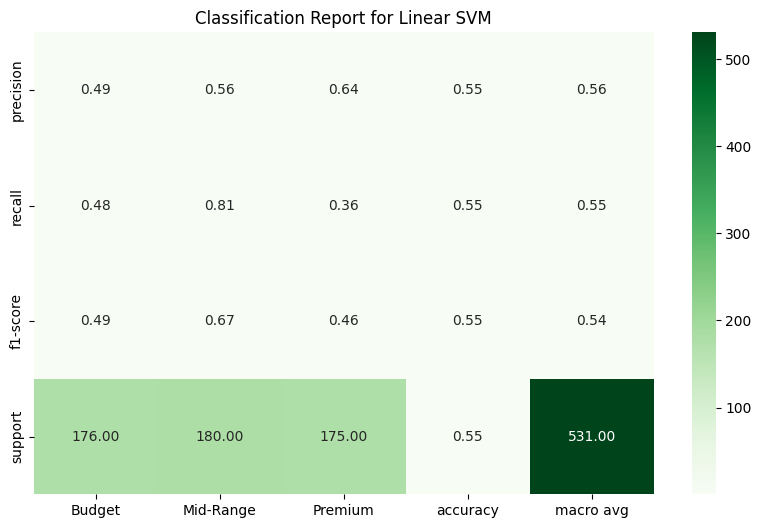

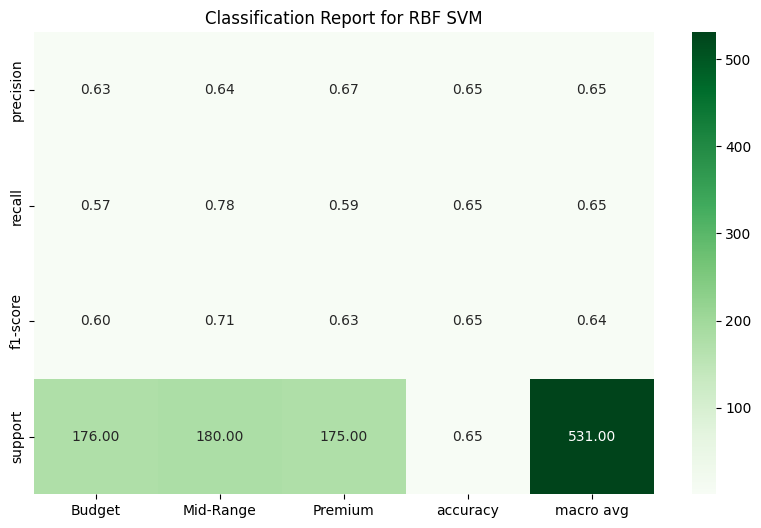

In [46]:
# 2. Classification Report Visualization (SVM)
report_dict_svm = classification_report(y_test,  y_pred_linear,  output_dict=True)
df_report_lisvm = pd.DataFrame(report_dict_svm).transpose()

report_dict_svm = classification_report(y_test, y_pred_rbf,  output_dict=True)
df_report_rbsvm = pd.DataFrame(report_dict_svm).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(df_report_lisvm.iloc[:-1, :].T, annot=True, cmap="Greens", fmt=".2f")
plt.title("Classification Report for Linear SVM")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df_report_rbsvm.iloc[:-1, :].T, annot=True, cmap="Greens", fmt=".2f")
plt.title("Classification Report for RBF SVM")
plt.show()
plt.close()

In [47]:
# Save Models & Scaler

joblib.dump(svm_linear, "smartphone_price_predictor_svm.pkl")
joblib.dump(svm_rbf, "smartphone_price_predictor_svm.pkl")
joblib.dump(scaler, "scaler_svm.pkl")


['scaler_svm.pkl']

ITBNM-2211-0132 (knn Model Training)

In [48]:
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [49]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
#Train-Test Split & Train Model (KNN)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_classification, test_size=0.3, random_state=42, stratify=y_classification)


#Train KNN Model 
knn_model = KNeighborsClassifier(n_neighbors=5) 
knn_model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [51]:

# Predict & Evaluate
knn_pred = knn_model.predict(X_test)
cm = confusion_matrix(y_test, knn_pred)

accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, knn_pred))

results = pd.DataFrame({
    "Model": ["KNN"],
    "Accuracy": [
       accuracy_score(y_test, knn_pred)
    ]
})


KNN Model Accuracy: 0.66

Classification Report:
               precision    recall  f1-score   support

      Budget       0.62      0.68      0.65       176
   Mid-Range       0.64      0.71      0.67       180
     Premium       0.73      0.58      0.65       175

    accuracy                           0.66       531
   macro avg       0.66      0.66      0.66       531
weighted avg       0.66      0.66      0.66       531



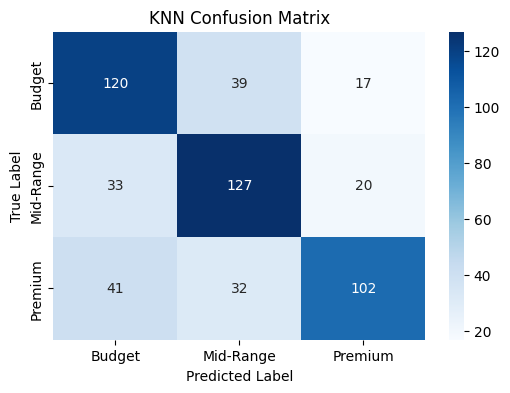

In [52]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN Confusion Matrix")
plt.show()

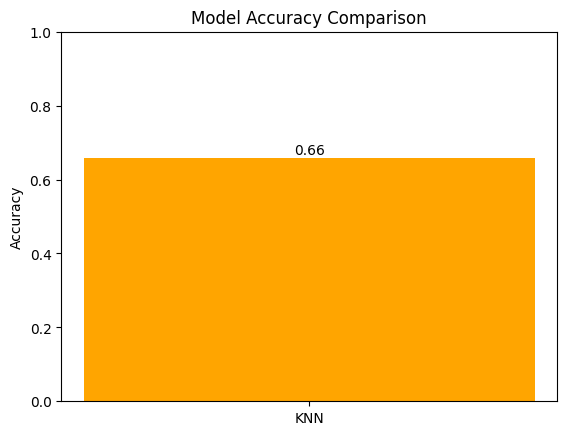

In [53]:
# Plot Results

plt.bar(results["Model"], results["Accuracy"], color=['orange'])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center')
plt.show()

In [54]:
#Save Models & Scaler

joblib.dump(knn_model, "smartphone_price_predictor_knn.pkl")
joblib.dump(scaler, "scaler_knn.pkl")

['scaler_knn.pkl']